Autor: Samantha Batisti  
Data: Março 2026

# Análise de Receita - Case Hotel

## Objetivo

O objetivo desta análise é identificar oportunidades para aumentar a receita anual do hotel em 20%.

A abordagem utilizada não se baseia apenas em prever receita futura, mas sim em identificar drivers operacionais de receita, como:

- comportamento de cancelamento
- canais de aquisição
- sazonalidade da demanda
- antecedência das reservas
- tipos de quarto,etc

A partir desses fatores, buscamos identificar *alavancas práticas de negócio* capazes de aumentar a receita do hotel.

## Metodologia de Análise

A análise será conduzida em três etapas principais:

1. Exploração inicial dos dados para compreender a estrutura do dataset e a qualidade das informações.
2. Criação de métricas de negócio relevantes, como duração total da estadia e estimativa de receita por reserva.
3. Análise exploratória para identificar padrões relacionados a cancelamentos, comportamento de reserva e drivers de receita.

## Perguntas de Negócio

Para orientar a análise, foram definidas algumas perguntas principais:

1. Como a receita do hotel está distribuída entre meses, segmentos e tipos de quarto?

2. Qual é a taxa de cancelamento e onde estão os principais vazamentos de receita?

3. Quais características das reservas estão associadas a maior probabilidade de cancelamento?

4. Quais segmentos e perfis de clientes geram maior valor para o hotel?

5. Quais alavancas operacionais podem contribuir para aumentar a receita do hotel?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

pd.set_option("display.max_columns", None)

In [2]:
arquivo = pd.ExcelFile(r"C:\Users\Samanta\Documents\hotel-case\data\Case Hotel BA .xlsx")
print(arquivo.sheet_names)

['Dicionário Candidato', 'Base de Dados']


In [3]:
dicionario = pd.read_excel(
    r"C:\Users\Samanta\Documents\hotel-case\data\Case Hotel BA .xlsx",
    sheet_name="Dicionário Candidato"
)

dicionario

,,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Nome Coluna,Descrição,NaN,NaN,alimentacao,significado
1,reserva_cancelada,1 = reserva cancelada | 0 = reserva mantida,NaN,NaN,BB,Café da Manhã (Bed and Breakfast)
2,tempo_antecedencia,Número de dias de antecedência da reserva fren...,NaN,NaN,FB,Alimentação livre (Full Board)
3,data_chegada,Data da chegada no hotel,NaN,NaN,HB,Café da Manhã + Outra refeição (Half Board)
4,ano_chegada,Ano da chegada no hotel,NaN,NaN,SC,Sem alimentação
5,mes_chegada,Mês da chegada no hotel,NaN,NaN,Undefined,Sem alimentação
6,diadomes_chegada,Dia do mês da chegada no hotel,NaN,NaN,NaN,NaN
7,nro_noites_fds,Números de noites de FDS de estadia (# Sábados...,NaN,NaN,segmento_mercado,significado
8,nro_noites_dds,Números de noites de DDS de estadia (# Seg - Sex),NaN,NaN,Corporativo,Corporativo
9,adultos,Número de adultos na reserva,NaN,NaN,Direta,Compra direta


# EDA

In [4]:
df = pd.read_excel(
    r"C:\Users\Samanta\Documents\hotel-case\data\Case Hotel BA .xlsx",
    sheet_name="Base de Dados"
)

**Entendimento inicial dos dados**

In [5]:
print("Linhas e colunas:", df.shape)
display(df.head())
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(15))

Linhas e colunas: (39859, 22)


,reserva_cancelada,tempo_antecedencia,data_chegada,ano_chegada,mes_chegada,diadomes_chegada,nro_noites_fds,nro_noites_dds,adultos,criancas,bebes,alimentacao,país,segmento_mercado,cliente_recorrente,tipo_quarto,tipo_pgto,agencia_turismo,receita_por_noite,pedidos_especiais,status_reserva,data_status_reserva
0,1,75,2015-07-01 00:00:00,2015,7,1,0,3,2,0,0,HB,PRT,AT Offline,0,D,Sem pgto,15.0,105.5,0,Cancelada,2015-04-22
1,1,85,2015-07-01 00:00:00,2015,7,1,0,3,2,0,0,BB,PRT,AT Online,0,A,Sem pgto,240.0,82.0,1,Cancelada,2015-05-06
2,1,60,2015-07-01 00:00:00,2015,7,1,2,5,2,0,0,BB,PRT,AT Online,0,E,Sem pgto,240.0,107.0,2,Cancelada,2015-05-11
3,1,96,2015-07-01 00:00:00,2015,7,1,2,8,2,0,0,BB,PRT,Direta,0,E,Sem pgto,NaN,108.3,2,Cancelada,2015-05-29
4,1,23,2015-07-01 00:00:00,2015,7,1,0,4,2,0,0,BB,PRT,AT Online,0,E,Sem pgto,240.0,123.0,0,Cancelada,2015-06-23


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39859 entries, 0 to 39858
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   reserva_cancelada    39859 non-null  int64         
 1   tempo_antecedencia   39859 non-null  int64         
 2   data_chegada         39859 non-null  object        
 3   ano_chegada          39859 non-null  int64         
 4   mes_chegada          39859 non-null  object        
 5   diadomes_chegada     39859 non-null  int64         
 6   nro_noites_fds       39859 non-null  int64         
 7   nro_noites_dds       39859 non-null  int64         
 8   adultos              39859 non-null  int64         
 9   criancas             39859 non-null  int64         
 10  bebes                39859 non-null  int64         
 11  alimentacao          39859 non-null  object        
 12  país                 39397 non-null  object        
 13  segmento_mercado     39859 non-

None

agencia_turismo       8058
país                   462
reserva_cancelada        0
tempo_antecedencia       0
status_reserva           0
pedidos_especiais        0
receita_por_noite        0
tipo_pgto                0
tipo_quarto              0
cliente_recorrente       0
segmento_mercado         0
alimentacao              0
bebes                    0
criancas                 0
adultos                  0
dtype: int64

In [6]:
df.describe()

,reserva_cancelada,tempo_antecedencia,ano_chegada,diadomes_chegada,nro_noites_fds,nro_noites_dds,adultos,criancas,bebes,cliente_recorrente,agencia_turismo,receita_por_noite,pedidos_especiais,data_status_reserva
count,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,31801.000000,39859.000000,39859.000000,39859
mean,0.278206,93.042098,2016.121252,15.814195,1.193382,3.136105,1.868562,0.129005,0.013874,0.044156,217.709192,95.413312,0.619007,2016-07-28 08:31:59.807320832
min,0.000000,0.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-6.380000,0.000000,2014-11-18 00:00:00
25%,0.000000,10.000000,2016.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,240.000000,50.400000,0.000000,2016-01-26 00:00:00
50%,0.000000,58.000000,2016.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,240.000000,75.650000,0.000000,2016-07-31 00:00:00
75%,1.000000,155.000000,2017.000000,24.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,242.000000,125.500000,1.000000,2017-02-11 00:00:00
max,1.000000,737.000000,2017.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,535.000000,508.000000,5.000000,2017-09-14 00:00:00
std,0.448121,97.365069,0.722550,8.884775,1.147829,2.461957,0.697594,0.445839,0.118884,0.205443,88.115646,61.245616,0.813391,NaN


## Data Prep
Nesta etapa foram feitos ajustes básicos, incluindo a criação da variável binária de cancelamento e padronizações.

In [7]:
# variável binária para cancelamento
df["reserva_cancelada"] = (df["status_reserva"] == "Cancelada").astype(int)

# mapa de mês numérico para nome
mapa_meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

df["mes_chegada_nome"] = df["mes_chegada"].map(mapa_meses)

ordem_meses = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]

df["mes_chegada_nome"] = pd.Categorical(
    df["mes_chegada_nome"],
    categories=ordem_meses,
    ordered=True
)

## Feature Engineering

Foram criadas variáveis derivadas relevantes para facilitar a análise de reservas e geração de receita.

In [8]:
# duração total da reserva
df["total_noites"] = df["nro_noites_fds"] + df["nro_noites_dds"]

# receita total da reserva
df["receita_reserva"] = df["receita_por_noite"] * df["total_noites"]

# total de hóspedes
df["total_hospedes"] = df["adultos"] + df["criancas"] + df["bebes"]

# reserva com crianças
df["reserva_com_criancas"] = (
    (df["criancas"] > 0) | (df["bebes"] > 0)
).astype(int)

# reserva apenas de fim de semana
df["somente_fim_de_semana"] = (
    (df["nro_noites_fds"] > 0) &
    (df["nro_noites_dds"] == 0)
).astype(int)

# reserva com pedido especial
df["tem_pedido_especial"] = (df["pedidos_especiais"] > 0).astype(int)

# faixa de antecedência da reserva
bins_antecedencia = [0, 7, 14, 30, 60, 90, 180, 365, 1000]
labels_antecedencia = ["0-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365", "365+"]

df["faixa_antecedencia"] = pd.cut(
    df["tempo_antecedencia"],
    bins=bins_antecedencia,
    labels=labels_antecedencia,
    include_lowest=True
)

# perfil de hóspedes
df["perfil_hospedes"] = pd.cut(
    df["total_hospedes"],
    bins=[0, 1, 2, 4, 20],
    labels=["solo", "casal", "familia_pequena", "grupo"],
    include_lowest=True
)

# perfil da estadia
df["perfil_estadia"] = np.where(
    df["nro_noites_fds"] > df["nro_noites_dds"],
    "lazer",
    "negocio"
)

# receita por hóspede
df["receita_por_hospede"] = np.where(
    df["total_hospedes"] > 0,
    df["receita_reserva"] / df["total_hospedes"],
    np.nan
)

In [9]:
df[[
    "total_noites",
    "receita_reserva",
    "total_hospedes",
    "reserva_com_criancas",
    "somente_fim_de_semana",
    "faixa_antecedencia",
    "perfil_hospedes",
    "perfil_estadia",
    "receita_por_hospede"
]].head()

,total_noites,receita_reserva,total_hospedes,reserva_com_criancas,somente_fim_de_semana,faixa_antecedencia,perfil_hospedes,perfil_estadia,receita_por_hospede
0,3,316.5,2,0,0,61-90,casal,negocio,158.25
1,3,246.0,2,0,0,61-90,casal,negocio,123.00
2,7,749.0,2,0,0,31-60,casal,negocio,374.50
3,10,1083.0,2,0,0,91-180,casal,negocio,541.50
4,4,492.0,2,0,0,15-30,casal,negocio,246.00


## Métricas gerais do negócio

Segue as principais métricas gerais da operação do hotel.

In [10]:
df_confirmadas = df[df["status_reserva"] == "Confirmada"].copy()

total_reservas = len(df)
reservas_confirmadas = (df["status_reserva"] == "Confirmada").sum()
reservas_canceladas = (df["status_reserva"] == "Cancelada").sum()
reservas_ausentes = (df["status_reserva"] == "Ausente").sum()

taxa_cancelamento = df["reserva_cancelada"].mean()
receita_total = df_confirmadas["receita_reserva"].sum()
adr = df_confirmadas["receita_por_noite"].mean()
estadia_media = df_confirmadas["total_noites"].mean()

print(f"Total de reservas: {total_reservas}")
print(f"Reservas confirmadas: {reservas_confirmadas}")
print(f"Reservas canceladas: {reservas_canceladas}")
print(f"Reservas ausentes: {reservas_ausentes}")
print(f"Taxa de cancelamento: {taxa_cancelamento:.2%}")
print(f"Receita total realizada: {receita_total:,.2f}")
print(f"ADR: {adr:,.2f}")
print(f"Estadia média: {estadia_media:.2f}")

Total de reservas: 39859
Reservas confirmadas: 28770
Reservas canceladas: 10802
Reservas ausentes: 287
Taxa de cancelamento: 27.10%
Receita total realizada: 11,599,780.70
ADR: 91.29
Estadia média: 4.15


# Análise exploratória de receita

## Receita por mes

C:\Users\Samanta\AppData\Local\Temp\ipykernel_27208\1079033232.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("mes_chegada_nome")["receita_reserva"]


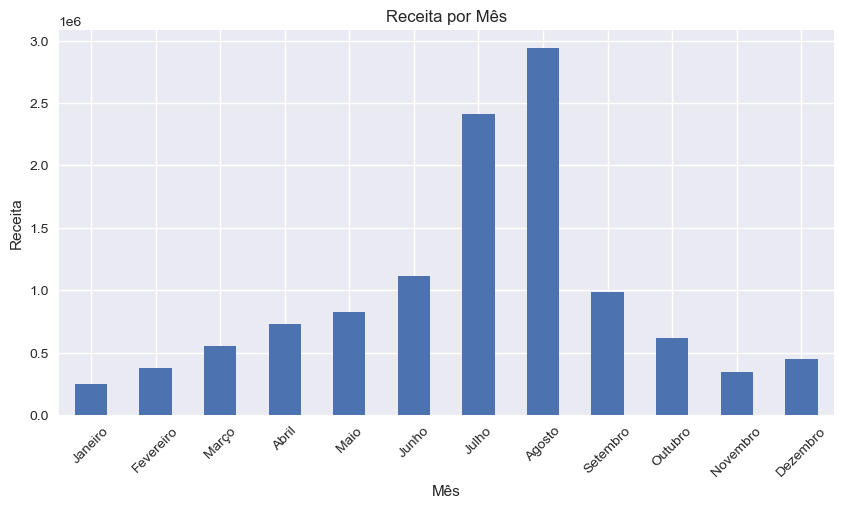

In [11]:
receita_mes = (
    df_confirmadas
    .groupby("mes_chegada_nome")["receita_reserva"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,5))
receita_mes.plot(kind="bar")
plt.title("Receita por Mês")
plt.ylabel("Receita")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.show()

## Receita por segmento de mercado

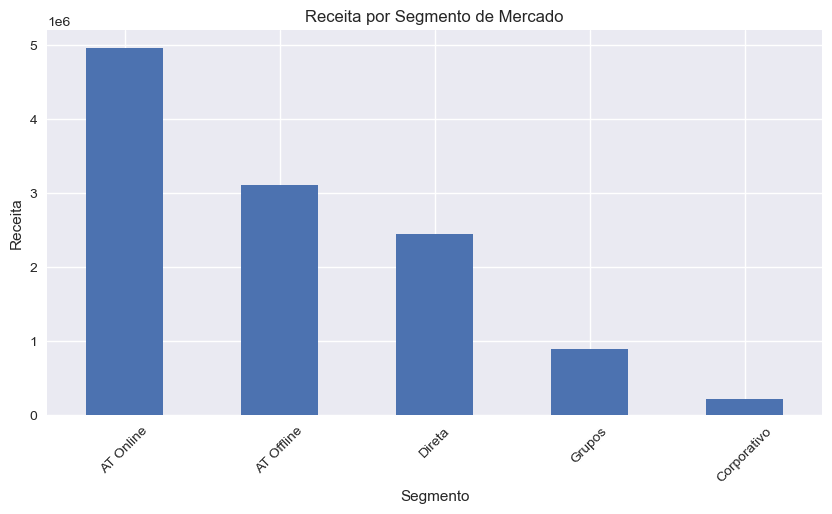

In [12]:
receita_segmento = (
    df_confirmadas
    .groupby("segmento_mercado")["receita_reserva"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
receita_segmento.plot(kind="bar")
plt.title("Receita por Segmento de Mercado")
plt.ylabel("Receita")
plt.xlabel("Segmento")
plt.xticks(rotation=45)
plt.show()

## Receita por tipo de quarto

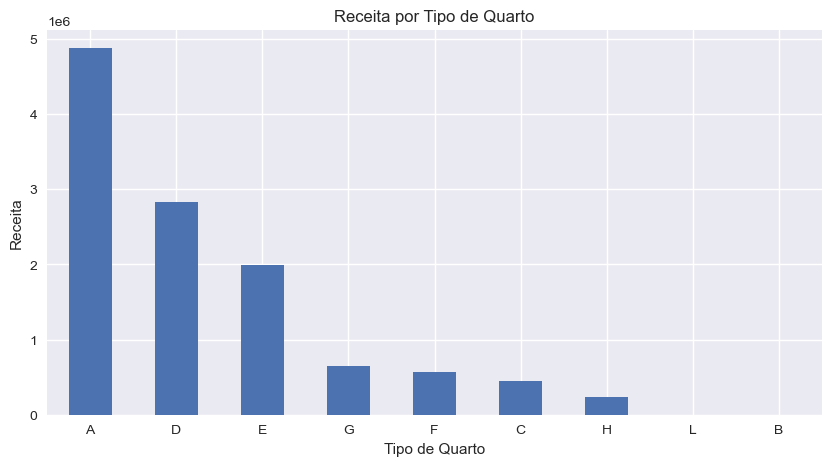

In [13]:
receita_quarto = (
    df_confirmadas
    .groupby("tipo_quarto")["receita_reserva"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
receita_quarto.plot(kind="bar")
plt.title("Receita por Tipo de Quarto")
plt.ylabel("Receita")
plt.xlabel("Tipo de Quarto")
plt.xticks(rotation=0)
plt.show()

## ADR por mês

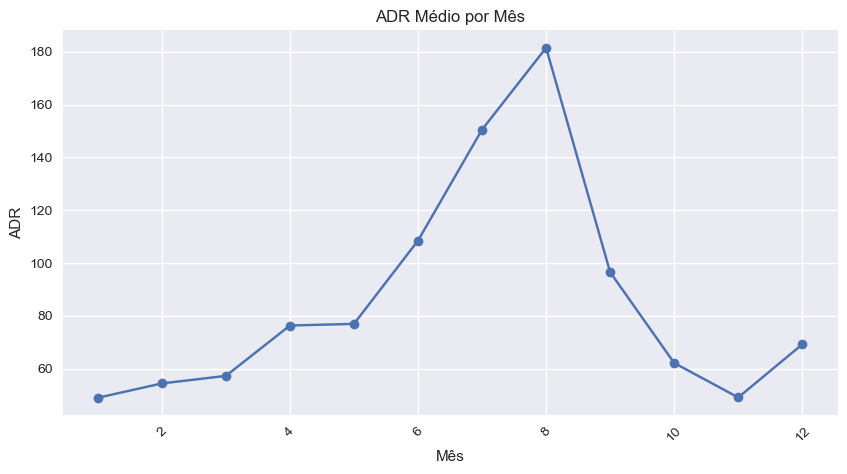

In [14]:
adr_mes = (
    df_confirmadas
    .groupby("mes_chegada")["receita_por_noite"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,5))
adr_mes.plot(kind="line", marker="o")
plt.title("ADR Médio por Mês")
plt.ylabel("ADR")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.show()

# Análise exploratória de cancelamento

## Taxa de cancelamento por faixa de antecedência

A hipótese principal desta análise é que reservas feitas com maior antecedência apresentam maior risco de cancelamento.

C:\Users\Samanta\AppData\Local\Temp\ipykernel_27208\1571906548.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_antecedencia")["reserva_cancelada"]


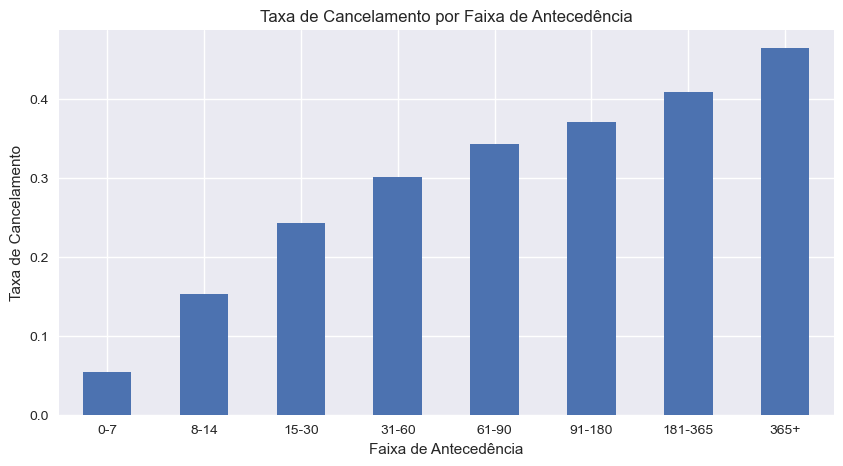

In [15]:
cancel_antecedencia = (
    df.groupby("faixa_antecedencia")["reserva_cancelada"]
    .mean()
)

plt.figure(figsize=(10,5))
cancel_antecedencia.plot(kind="bar")
plt.title("Taxa de Cancelamento por Faixa de Antecedência")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Faixa de Antecedência")
plt.xticks(rotation=0)
plt.show()

In [16]:
(
    df.groupby("faixa_antecedencia")
    .agg(
        reservas=("reserva_cancelada", "count"),
        taxa_cancelamento=("reserva_cancelada", "mean")
    )
)

C:\Users\Samanta\AppData\Local\Temp\ipykernel_27208\1859383803.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_antecedencia")


,reservas,taxa_cancelamento
faixa_antecedencia,,
0-7,8838,0.053519
8-14,2423,0.152703
15-30,3920,0.243112
31-60,5062,0.300672
61-90,3666,0.342608
91-180,8207,0.370415
181-365,7299,0.408549
365+,444,0.463964


## Taxa de cancelamento por segmento

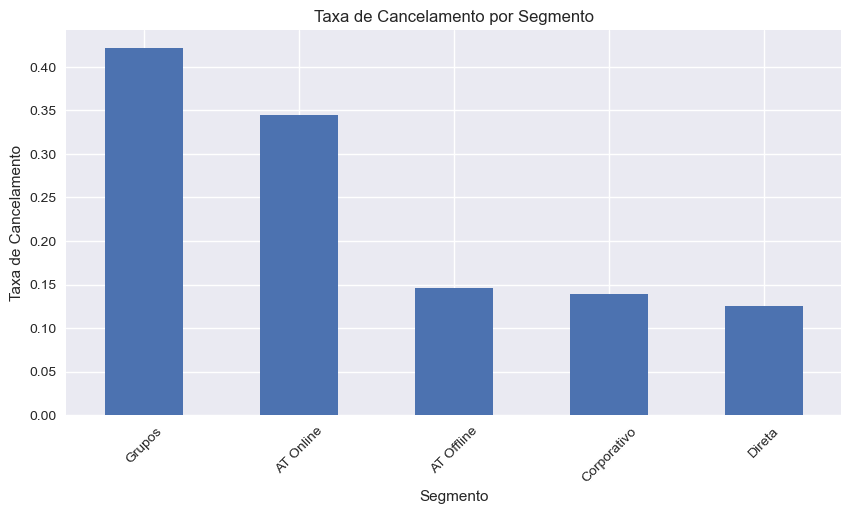

In [17]:
cancel_segmento = (
    df.groupby("segmento_mercado")["reserva_cancelada"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
cancel_segmento.plot(kind="bar")
plt.title("Taxa de Cancelamento por Segmento")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Segmento")
plt.xticks(rotation=45)
plt.show()

## Taxa de cancelamento por recorrência

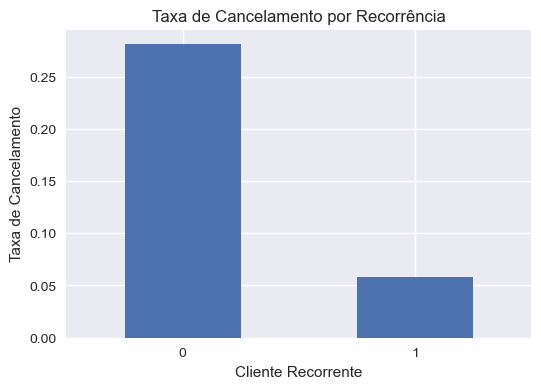

In [18]:
cancel_recorrente = (
    df.groupby("cliente_recorrente")["reserva_cancelada"]
    .mean()
)

plt.figure(figsize=(6,4))
cancel_recorrente.plot(kind="bar")
plt.title("Taxa de Cancelamento por Recorrência")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Cliente Recorrente")
plt.xticks(rotation=0)
plt.show()

## Taxa de cancelamento por pedidos especiais


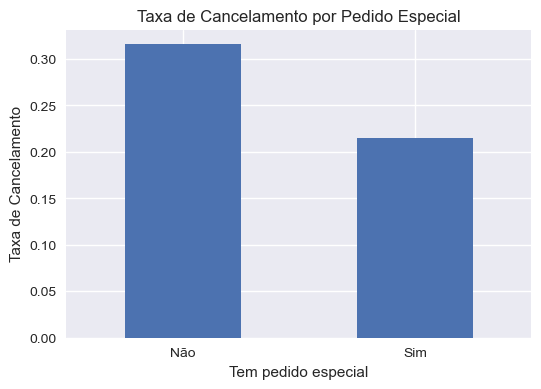

In [19]:
cancel_pedido = (
    df.groupby("tem_pedido_especial")["reserva_cancelada"]
    .mean()
)

plt.figure(figsize=(6,4))
cancel_pedido.plot(kind="bar")
plt.title("Taxa de Cancelamento por Pedido Especial")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Tem pedido especial")
plt.xticks([0,1], ["Não", "Sim"], rotation=0)
plt.show()

# Principais drivers

## Tabela executiva por segmento

A tabela abaixo consolida volume, risco de cancelamento, receita e antecedência média por segmento.

In [20]:
resumo_segmento = (
    df.groupby("segmento_mercado")
    .agg(
        reservas=("segmento_mercado", "count"),
        taxa_cancelamento=("reserva_cancelada", "mean"),
        receita_total=("receita_reserva", "sum"),
        antecedencia_media=("tempo_antecedencia", "mean")
    )
    .sort_values("receita_total", ascending=False)
)

resumo_segmento

,reservas,taxa_cancelamento,receita_total,antecedencia_media
segmento_mercado,,,,
AT Online,17729,0.344859,8956803.08,83.270968
AT Offline,7472,0.146012,3676710.75,120.452489
Direta,6513,0.125595,2970496.88,48.457546
Grupos,5836,0.421350,1547645.69,167.213331
Corporativo,2309,0.138588,290226.64,17.657861


## Resumo dos principais drivers identificados

In [21]:
insights = pd.DataFrame({
    "driver": [
        "Antecedência da reserva",
        "Mix de segmentos",
        "Recorrência",
        "Pedidos especiais",
        "Sazonalidade"
    ],
    "evidencia": [
        "A taxa de cancelamento aumenta conforme cresce a antecedência",
        "Alguns segmentos concentram receita, mas também maior risco",
        "Clientes recorrentes tendem a cancelar menos",
        "Reservas com pedidos especiais parecem ter maior intenção real",
        "Receita e ADR se concentram em determinados meses"
    ],
    "implicacao_negocio": [
        "Revisar política comercial para reservas muito antecipadas",
        "Otimizar mix de canais e qualidade da aquisição",
        "Fortalecer ações de retenção e recompra",
        "Usar sinais comportamentais para priorização em CRM",
        "Aplicar estratégias de pricing e gestão de demanda"
    ]
})

insights

,driver,evidencia,implicacao_negocio
0,Antecedência da reserva,A taxa de cancelamento aumenta conforme cresce...,Revisar política comercial para reservas muito...
1,Mix de segmentos,"Alguns segmentos concentram receita, mas també...",Otimizar mix de canais e qualidade da aquisição
2,Recorrência,Clientes recorrentes tendem a cancelar menos,Fortalecer ações de retenção e recompra
3,Pedidos especiais,Reservas com pedidos especiais parecem ter mai...,Usar sinais comportamentais para priorização e...
4,Sazonalidade,Receita e ADR se concentram em determinados meses,Aplicar estratégias de pricing e gestão de dem...


# Análise de Períodos Anuais Fechados

A base de dados cobre 26 meses (Jul/2015 a Ago/2017), o que não corresponde a anos-calendário completos. Para uma análise temporal mais precisa, foram construídos **dois períodos anuais de 12 meses cada**:

- **Ano 1:** Jul/2015 a Jun/2016
- **Ano 2:** Jul/2016 a Jun/2017

Essa abordagem permite comparar a evolução do hotel de forma justa, eliminando distorções de períodos incompletos.

In [23]:
# Definir os dois períodos anuais completos
df['periodo'] = None

# Limpar valores inválidos antes de converter
df['data_chegada'] = pd.to_datetime(df['data_chegada'], errors='coerce')

# Remover linhas onde a data não foi convertida
print(f"Linhas com data inválida: {df['data_chegada'].isna().sum()}")
df = df.dropna(subset=['data_chegada'])

mask_p1 = (df['data_chegada'] >= pd.Timestamp('2015-07-01')) & (df['data_chegada'] <= pd.Timestamp('2016-06-30'))
mask_p2 = (df['data_chegada'] >= pd.Timestamp('2016-07-01')) & (df['data_chegada'] <= pd.Timestamp('2017-06-30'))
df.loc[mask_p1, 'periodo'] = 'Ano 1 (Jul/15-Jun/16)'
df.loc[mask_p2, 'periodo'] = 'Ano 2 (Jul/16-Jun/17)'

# Filtrar apenas os 2 períodos
dp = df[df['periodo'].notna()].copy()
conf_p = dp[dp['reserva_cancelada'] == False]

# Visão geral por período
visao_geral = []
for periodo in ['Ano 1 (Jul/15-Jun/16)', 'Ano 2 (Jul/16-Jun/17)']:
    t = dp[dp['periodo'] == periodo]
    c = conf_p[conf_p['periodo'] == periodo]
    visao_geral.append({
        'Período': periodo,
        'Receita Total': f"R$ {c['receita_reserva'].sum():,.0f}",
        'Total Reservas': f"{len(t):,}",
        'Confirmadas': f"{len(c):,}",
        'Taxa Cancel.': f"{(t['reserva_cancelada'].sum() / len(t) * 100):.1f}%",
        'ADR Médio': f"R$ {c['receita_por_noite'].mean():.2f}",
        'Noites Médias': f"{c['total_noites'].mean():.2f}",
        'Receita Média/Reserva': f"R$ {c['receita_reserva'].mean():.2f}"
    })

df_visao = pd.DataFrame(visao_geral)
display(df_visao)




Linhas com data inválida: 1


,Período,Receita Total,Total Reservas,Confirmadas,Taxa Cancel.,ADR Médio,Noites Médias,Receita Média/Reserva
0,Ano 1 (Jul/15-Jun/16),"R$ 4,369,129","17,456","13,191",24.4%,R$ 77.03,3.98,R$ 331.22
1,Ano 2 (Jul/16-Jun/17),"R$ 5,261,965","18,858","13,651",27.6%,R$ 89.30,4.15,R$ 385.46


## Decomposição do Crescimento de 20,4%

O hotel apresentou crescimento de 20,4% na receita entre os dois períodos. A decomposição abaixo identifica **quanto cada fator contribuiu** para esse delta.

In [25]:
# Dados dos dois períodos
c1 = conf_p[conf_p['periodo'] == 'Ano 1 (Jul/15-Jun/16)']
c2 = conf_p[conf_p['periodo'] == 'Ano 2 (Jul/16-Jun/17)']

rec1 = c1['receita_reserva'].sum()
rec2 = c2['receita_reserva'].sum()
delta = rec2 - rec1

vol1, vol2 = len(c1), len(c2)
adr1 = c1['receita_por_noite'].mean()
adr2 = c2['receita_por_noite'].mean()
noites1 = c1['total_noites'].mean()
noites2 = c2['total_noites'].mean()

# Contribuição de cada fator (decomposição aditiva)
efeito_volume = (vol2 - vol1) * adr1 * noites1
efeito_adr = vol1 * (adr2 - adr1) * noites1
efeito_noites = vol1 * adr1 * (noites2 - noites1)
efeitos_cruzados = delta - efeito_volume - efeito_adr - efeito_noites

print(f"Receita Ano 1: R$ {rec1:,.2f}")
print(f"Receita Ano 2: R$ {rec2:,.2f}")
print(f"Delta: R$ {delta:,.2f} (+{delta/rec1*100:.1f}%)")
print(f"\nDecomposição:")
print(f"  Volume (reservas): {vol1:,} → {vol2:,} ({(vol2-vol1)/vol1*100:+.1f}%)")
print(f"  ADR médio: R$ {adr1:.2f} → R$ {adr2:.2f} ({(adr2-adr1)/adr1*100:+.1f}%)")
print(f"  Noites médias: {noites1:.2f} → {noites2:.2f} ({(noites2-noites1)/noites1*100:+.1f}%)")
print(f"\nContribuição ao delta de R$ {delta:,.0f}:")
print(f"  Efeito Volume: R$ {efeito_volume:,.0f} ({efeito_volume/delta*100:.0f}%)")
print(f"  Efeito ADR (Preço): R$ {efeito_adr:,.0f} ({efeito_adr/delta*100:.0f}%)")
print(f"  Efeito Noites (Estadia): R$ {efeito_noites:,.0f} ({efeito_noites/delta*100:.0f}%)")
print(f"  Efeitos cruzados: R$ {efeitos_cruzados:,.0f}")

Receita Ano 1: R$ 4,369,129.29
Receita Ano 2: R$ 5,261,964.94
Delta: R$ 892,835.65 (+20.4%)

Decomposição:
  Volume (reservas): 13,191 → 13,651 (+3.5%)
  ADR médio: R$ 77.03 → R$ 89.30 (+15.9%)
  Noites médias: 3.98 → 4.15 (+4.3%)

Contribuição ao delta de R$ 892,836:
  Efeito Volume: R$ 141,182 (16%)
  Efeito ADR (Preço): R$ 644,489 (72%)
  Efeito Noites (Estadia): R$ 172,639 (19%)
  Efeitos cruzados: R$ -65,474


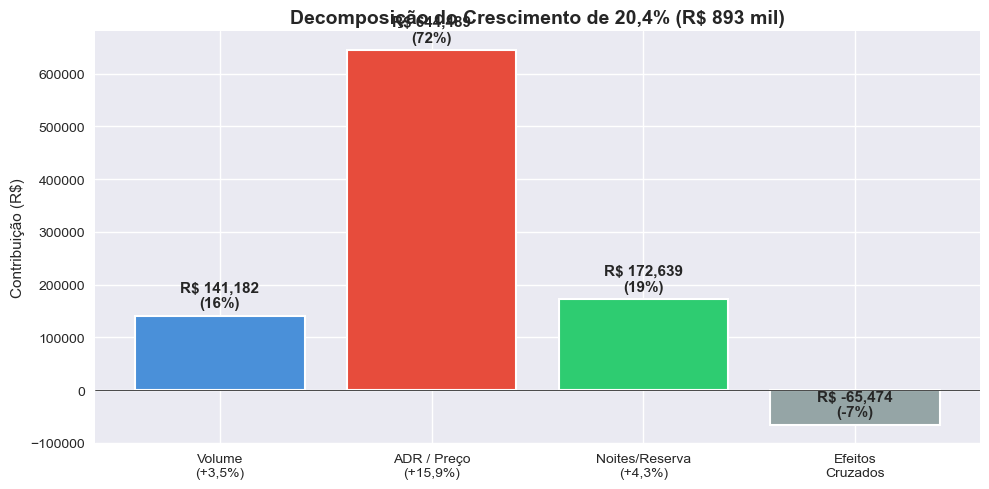

In [26]:
# Gráfico de decomposição do crescimento
fatores = ['Volume\n(+3,5%)', 'ADR / Preço\n(+15,9%)', 'Noites/Reserva\n(+4,3%)', 'Efeitos\nCruzados']
valores = [efeito_volume, efeito_adr, efeito_noites, efeitos_cruzados]
cores = ['#4A90D9', '#E74C3C', '#2ECC71', '#95A5A6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fatores, valores, color=cores, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'R$ {val:,.0f}\n({val/delta*100:.0f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Decomposição do Crescimento de 20,4% (R$ 893 mil)', fontsize=14, fontweight='bold')
ax.set_ylabel('Contribuição (R$)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## ADR por Mês: Ano 1 vs Ano 2

O ADR subiu em **todos os 12 meses**, com os maiores aumentos nos meses de alta temporada (Abr +28%, Jul +23%, Ago +22%). Isso sugere que o hotel já praticava algum nível de precificação por demanda.

C:\Users\Samanta\AppData\Local\Temp\ipykernel_27208\3727778587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  conf_p['mes_num'] = conf_p['data_chegada'].dt.month


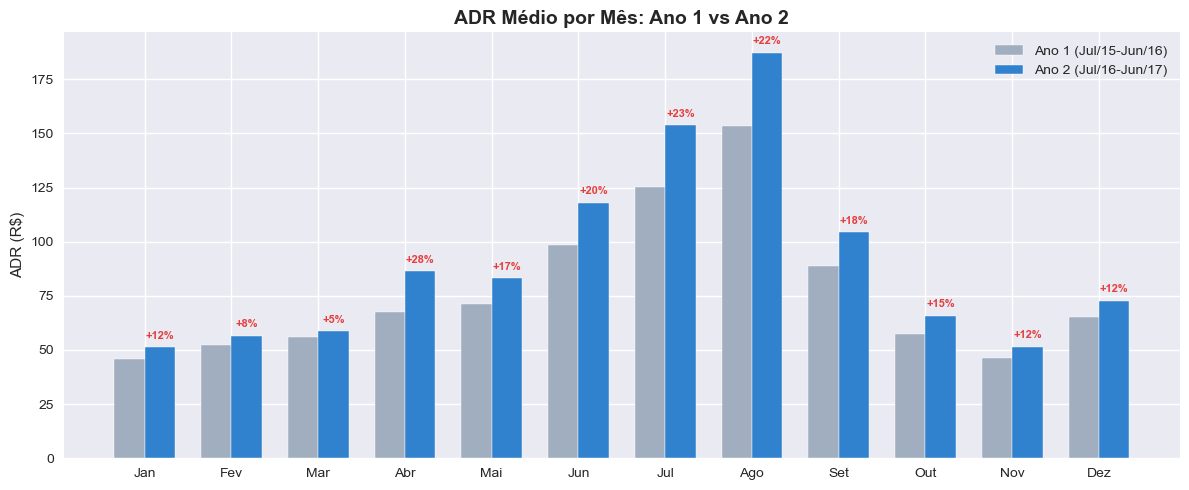

In [27]:
# ADR por mês - comparativo Ano 1 vs Ano 2
conf_p['mes_num'] = conf_p['data_chegada'].dt.month
meses_nomes = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
               7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

adr_p1 = conf_p[conf_p['periodo'] == 'Ano 1 (Jul/15-Jun/16)'].groupby('mes_num')['receita_por_noite'].mean()
adr_p2 = conf_p[conf_p['periodo'] == 'Ano 2 (Jul/16-Jun/17)'].groupby('mes_num')['receita_por_noite'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = range(1, 13)
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], [adr_p1.get(m, 0) for m in x], width,
               label='Ano 1 (Jul/15-Jun/16)', color='#A0AEC0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], [adr_p2.get(m, 0) for m in x], width,
               label='Ano 2 (Jul/16-Jun/17)', color='#3182CE', edgecolor='white')

# Adicionar variação percentual
for m in x:
    v1 = adr_p1.get(m, 0)
    v2 = adr_p2.get(m, 0)
    if v1 > 0:
        var = (v2 - v1) / v1 * 100
        ax.text(m + width/2, v2 + 3, f'+{var:.0f}%', ha='center', va='bottom',
                fontsize=8, color='#E53E3E', fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels([meses_nomes[m] for m in x])
ax.set_title('ADR Médio por Mês: Ano 1 vs Ano 2', fontsize=14, fontweight='bold')
ax.set_ylabel('ADR (R$)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Efeitos Colaterais do Crescimento

Embora a receita tenha crescido 20,4%, o crescimento veio acompanhado de efeitos negativos que precisam ser corrigidos na próxima estratégia.

In [29]:
# Comparativo de KPIs entre os dois períodos
t1 = dp[dp['periodo'] == 'Ano 1 (Jul/15-Jun/16)']
t2 = dp[dp['periodo'] == 'Ano 2 (Jul/16-Jun/17)']

# Taxa cancelamento AT Online
at_online_1 = t1[t1['segmento_mercado'] == 'AT Online']
at_online_2 = t2[t2['segmento_mercado'] == 'AT Online']
cancel_at1 = at_online_1['reserva_cancelada'].mean() * 100
cancel_at2 = at_online_2['reserva_cancelada'].mean() * 100

# % Receita AT Online
pct_at1 = c1[c1['segmento_mercado'] == 'AT Online']['receita_reserva'].sum() / rec1 * 100
pct_at2 = c2[c2['segmento_mercado'] == 'AT Online']['receita_reserva'].sum() / rec2 * 100

# % Receita Direta
pct_dir1 = c1[c1['segmento_mercado'] == 'Direta']['receita_reserva'].sum() / rec1 * 100
pct_dir2 = c2[c2['segmento_mercado'] == 'Direta']['receita_reserva'].sum() / rec2 * 100

# Recorrência
rec_rate1 = t1['cliente_recorrente'].mean() * 100
rec_rate2 = t2['cliente_recorrente'].mean() * 100

efeitos = pd.DataFrame({
    'KPI': ['Taxa de Cancelamento Geral', 'Cancel. AT Online', '% Receita AT Online',
            '% Receita Direta', 'Clientes Recorrentes'],
    'Ano 1': [f"{t1['reserva_cancelada'].mean()*100:.1f}%", f"{cancel_at1:.1f}%",
              f"{pct_at1:.1f}%", f"{pct_dir1:.1f}%", f"{rec_rate1:.2f}%"],
    'Ano 2': [f"{t2['reserva_cancelada'].mean()*100:.1f}%", f"{cancel_at2:.1f}%",
              f"{pct_at2:.1f}%", f"{pct_dir2:.1f}%", f"{rec_rate2:.2f}%"],
    'Tendência': ['Piorou', 'Piorou significativamente', ' Maior dependência',
                  ' Estável', ' Melhorou levemente']
})

display(efeitos)

,KPI,Ano 1,Ano 2,Tendência
0,Taxa de Cancelamento Geral,24.4%,27.6%,Piorou
1,Cancel. AT Online,27.2%,36.8%,Piorou significativamente
2,% Receita AT Online,37.4%,43.5%,Maior dependência
3,% Receita Direta,20.0%,20.1%,Estável
4,Clientes Recorrentes,3.71%,5.35%,Melhorou levemente


## Conclusão da Análise de Períodos

**O crescimento de 20,4% entre os dois períodos foi real, mas não sustentável.** A decomposição revela que:

- **72% do crescimento veio do aumento de ADR** (preço), não de volume ou eficiência
- **Cancelamentos aumentaram** de 24,4% para 27,6%, especialmente em AT Online (27% → 37%)
- **Dependência de agências online cresceu** de 37% para 44% da receita
- **Canal direto ficou estagnado** em ~20%

Isso reforça que a estratégia de crescimento precisa ser **multidimensional**: não basta subir preço. É necessário reduzir cancelamentos, diversificar canais e aumentar fidelização para que o próximo ciclo de crescimento seja sustentável.

# Cenários de aumento de receita

Em vez de projetar a receita apenas por técnicas de série temporal, foi adotada uma abordagem orientada a drivers de negócio, com simulações de alavancas práticas.

In [30]:
receita_atual = df_confirmadas["receita_reserva"].sum()

canceladas_online = df[
    (df["segmento_mercado"] == "AT Online") &
    (df["status_reserva"] == "Cancelada")
]["receita_reserva"].sum()

canceladas_grupos = df[
    (df["segmento_mercado"] == "Grupos") &
    (df["status_reserva"] == "Cancelada")
]["receita_reserva"].sum()

receita_direta = df_confirmadas[
    df_confirmadas["segmento_mercado"] == "Direta"
]["receita_reserva"].sum()

receita_jul_ago = df_confirmadas[
    df_confirmadas["mes_chegada_nome"].isin(["Julho", "Agosto"])
]["receita_reserva"].sum()

## As porcentagens de uplift usadas abaixo são hipóteses conservadoras baseadas em benchmarks de hotelaria e no impacto esperado de cada alavanca, evitando superestimar o potencial de crescimento.

In [31]:
uplift_online = canceladas_online * 0.05
uplift_grupos = canceladas_grupos * 0.08
uplift_direta = receita_direta * 0.10
uplift_pricing = receita_jul_ago * 0.03

cenarios = pd.DataFrame({
    "alavanca": [
        "Redução de cancelamento em AT Online",
        "Redução de cancelamento em Grupos",
        "Crescimento do canal Direta",
        "Aumento de preço em Julho e Agosto"
    ],
    "hipotese": [
        "redução de 5 p.p. no cancelamento",
        "redução de 8 p.p. no cancelamento",
        "crescimento de 10% na receita do canal",
        "aumento de 3% no preço em meses de pico"
    ],
    "upside_estimado": [
        uplift_online,
        uplift_grupos,
        uplift_direta,
        uplift_pricing
    ]
})

cenarios["% da receita atual"] = cenarios["upside_estimado"] / receita_atual
cenarios

,alavanca,hipotese,upside_estimado,% da receita atual
0,Redução de cancelamento em AT Online,redução de 5 p.p. no cancelamento,198054.3220,0.017074
1,Redução de cancelamento em Grupos,redução de 8 p.p. no cancelamento,52630.1944,0.004537
2,Crescimento do canal Direta,crescimento de 10% na receita do canal,244186.8500,0.021051
3,Aumento de preço em Julho e Agosto,aumento de 3% no preço em meses de pico,160569.3771,0.013842


In [ ]:
upside_total = cenarios["upside_estimado"].sum()
pct_total = upside_total / receita_atual

print(f"Upside total estimado: {upside_total:,.2f}")
print(f"Upside sobre a receita atual: {pct_total:.2%}")

Upside total estimado: 655,448.12
Upside sobre a receita atual: 5.65%


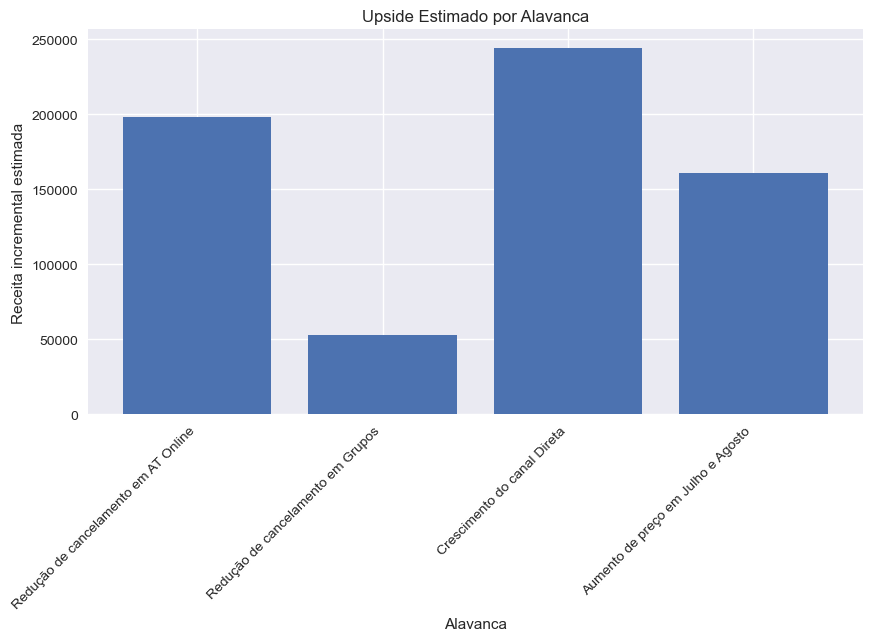

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(cenarios["alavanca"], cenarios["upside_estimado"])
plt.title("Upside Estimado por Alavanca")
plt.ylabel("Receita incremental estimada")
plt.xlabel("Alavanca")
plt.xticks(rotation=45, ha="right")
plt.show()

# Conclusões e recomendações

A análise mostra que o principal desafio do hotel não parece ser apenas gerar mais reservas, mas sim aumentar a qualidade e a conversão das reservas já existentes.

## Principais conclusões

- a taxa de cancelamento é elevada e representa um importante vazamento de receita
- reservas feitas com maior antecedência apresentam maior risco de cancelamento
- há diferenças relevantes entre segmentos em termos de receita e qualidade da reserva
- o hotel apresenta sazonalidade, com oportunidade de gestão de preço em períodos de pico
- sinais comportamentais como recorrência e pedidos especiais podem ajudar a identificar reservas de maior qualidade

## Recomendações prioritárias

1. Rever a política comercial para reservas feitas com muita antecedência
2. Melhorar o mix de segmentos e fortalecer canais mais saudáveis
3. Incentivar recorrência e canal direto
4. Aplicar pricing mais agressivo em períodos de maior demanda
5. Explorar estratégias de upsell em tipos de quarto com maior valor

In [ ]:
base_pbi = df.copy()

base_pbi.to_excel("base_final_hotel_pbi.xlsx", index=False)

print("Base exportada com sucesso.")

Base exportada com sucesso.
